# QuantOm Artifact Walkthrough

This notebook provides a lightweight entry point for the QuantOm artifact.
It is intended to:

1. show the repository layout,
2. explain the `make` workflow,
3. regenerate figures from archived results,
4. optionally rerun experiments,
5. display the generated figures used in the paper.

---

## Recommended usage

 From the repository root:

 - `make` regenerates figures from the local `results/` directory
 - if `results/` does not exist, the plotting scripts bootstrap it from `archived-results/`
 - `make rerun-strong` reruns the strong-scaling experiments
 - `make rerun-weak` reruns the weak-scaling experiments
 - `make rerun-frs` reruns the fixed-resource-scaling experiments

 In general:

 - use `make` for quick artifact validation,
 - use the `rerun-*` targets only when collecting fresh measurements on a new system.

In [6]:
# %%
from pathlib import Path
import os
import subprocess
import textwrap

ROOT = Path.cwd()
print("Notebook working directory:", ROOT)

Notebook working directory: /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC


## Repository layout

 The artifact is organized around:

 - `cpp/` : native C++ pybind wrapper
 - `omp/` : OpenMP pybind wrapper
 - `sycl/` : SYCL wrappers and backend-specific builds
 - `images/` : generated paper figures
 - `archived-results/` : archived results shipped with the artifact
 - `results/` : working results directory used by plotting / rerun scripts
 - `plot_strong_scaling.sh` : regenerates the strong-scaling figure
 - `plot_weak_scaling.sh` : regenerates the weak-scaling figure
 - `plot_fixed_resource_and_stacked.sh` : regenerates the fixed-resource and breakdown figures

In [9]:
# %%
for p in sorted(ROOT.iterdir()):
    print(p.name + ("/" if p.is_dir() else ""))

.Makefile.swp
.README.md.swp
.git/
.gitignore
.gitignore.swp
.ipynb_checkpoints/
.pixi/
.plot_fixed_resource_and_stacked.sh.swp
.plot_strong_scaling.sh.swp
.plot_weak_scaling.sh.swp
.setup-backends.sh.swp
.utils.sh.swp
Makefile
README.md
__pycache__/
archived-results/
artifact_walkthrough.ipynb
common/
cpp/
images/
makefile_defs.mk
memory_footprints.csv
omp/
pixi.lock
pixi.toml
plot_fixed_resource_and_stacked.sh
plot_strong_scaling.sh
plot_weak_scaling.sh
profile_2dloits_performance.sh
pytorch_2dloits.py
results/
results_loits_performance_scans/
run.sh
setup-backends.sh
sycl/
torch_2D_inverse_transform_sampler.py
torch_proxy_theory_lite.py
utils/
utils.py
utils.sh


 ## Make targets

 The main targets are:

 - `make`
   - regenerate all figures from `results/`

 - `make rerun-strong`
   - rerun strong-scaling experiments and regenerate the strong-scaling figure

 - `make rerun-weak`
   - rerun weak-scaling experiments and regenerate the weak-scaling figure

 - `make rerun-frs`
   - rerun fixed-resource-scaling experiments and regenerate the fixed-resource / stacked figures

 - `make clean`
   - remove built wrappers and generated SYCL artifacts

 ---

 For a quick artifact demonstration, start with:

 ```bash
 make
 ```

 For fresh measurements on the current system:

 ```bash
 make rerun-strong
 make rerun-weak
 make rerun-frs
 ```

In [11]:
# %%
makefile = ROOT / "Makefile"
if makefile.exists():
    print(makefile.read_text()[:4000])
else:
    print("Makefile not found.")

.PHONY: all plot plot-strong plot-weak plot-frs \
        install reinstall \
        build build-cpp build-omp build-sycl \
        build-sycl-acpp build-sycl-tbb build-sycl-cuda build-sycl-hip build-sycl-xpu \
        rerun rerun-strong rerun-weak rerun-frs \
        rerun-frs-cpu rerun-frs-cuda rerun-frs-hip rerun-frs-xpu \
        clean clean-cpp clean-omp clean-sycl \
        smoke scaling profile debug \
        test test-cpp test-omp test-sycl \
        test-omp-basic test-omp-instrument test-omp-flto test-omp-instrument-flto \
        test-sycl-acpp test-sycl-acpp-omp test-sycl-acpp-cuda \
        test-sycl-dpcpp-cuda test-sycl-dpcpp-hip test-sycl-usy

SHELL := /usr/bin/env bash

# Default: regenerate figures from results/ only
all: plot

# -------------------------
# Plotting
# -------------------------

plot: plot-strong plot-weak plot-frs

plot-strong:
	./plot_strong_scaling.sh

plot-weak:
	./plot_weak_scaling.sh

plot-frs:
	./plot_fixed_resource_and_stacked.sh

# ----------

 ## Quick artifact validation

 This is the recommended first step.
 
 It should:

 - bootstrap `results/` from `archived-results/` if needed,
 - regenerate the paper figures,
 - leave archived results untouched.

 Uncomment the next cell to run it.

In [15]:
run("make")

$ make
./plot_strong_scaling.sh
Setting up backends for milan2
['OpenMP' 'SYCL AdaptiveCpp (OpenMP)' 'PyTorch (CPU)' 'C++'
 'SYCL DPC++ (TBB)']
Wrote /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/strong_scaling.png
./plot_weak_scaling.sh
Setting up backends for milan2
['OpenMP' 'C++' 'PyTorch (CPU)' 'SYCL AdaptiveCpp (OpenMP)'
 'SYCL DPC++ (TBB)']
Wrote /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/weak_scaling.png
./plot_fixed_resource_and_stacked.sh
Setting up backends for milan2
Wrote /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/cpu_scaling.png
Wrote /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/gpu_scaling.png
Wrote /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/stacked_barplot_cpu.pdf
Wrote /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/stacked_barplot_gpu.pdf

Note Well: This is a

CompletedProcess(args='make', returncode=0, stdout="./plot_strong_scaling.sh\nSetting up backends for milan2\n['OpenMP' 'SYCL AdaptiveCpp (OpenMP)' 'PyTorch (CPU)' 'C++'\n 'SYCL DPC++ (TBB)']\nWrote /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/strong_scaling.png\n./plot_weak_scaling.sh\nSetting up backends for milan2\n['OpenMP' 'C++' 'PyTorch (CPU)' 'SYCL AdaptiveCpp (OpenMP)'\n 'SYCL DPC++ (TBB)']\nWrote /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/weak_scaling.png\n./plot_fixed_resource_and_stacked.sh\nSetting up backends for milan2\nWrote /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/cpu_scaling.png\nWrote /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/gpu_scaling.png\nWrote /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/stacked_barplot_cpu.pdf\nWrote /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-

 ## Optional: rerun experiments

 These commands are substantially more expensive than `make`.
 Use them only if you want to collect fresh measurements on the current system.

 Uncomment one at a time as needed.

In [16]:
# %%
# run("make rerun-strong")
# run("make rerun-weak")
# run("make rerun-frs")

 ## Display generated figures

 The following cells show the figures used in the paper.

In [17]:
# %%
from IPython.display import Image, display, Markdown

In [19]:
# %%
strong = ROOT / "images" / "strong_scaling.png"
weak = ROOT / "images" / "weak_scaling.png"
cpu = ROOT / "images" / "cpu_scaling.png"
gpu = ROOT / "images" / "gpu_scaling.png"

for label, path in [
    ("Strong scaling", strong),
    ("Weak scaling", weak),
    ("CPU fixed-resource scaling", cpu),
    ("GPU fixed-resource scaling", gpu),
]:
    print(f"{label}: {'FOUND' if path.exists() else 'MISSING'} -> {path}")

Strong scaling: FOUND -> /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/strong_scaling.png
Weak scaling: FOUND -> /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/weak_scaling.png
CPU fixed-resource scaling: FOUND -> /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/cpu_scaling.png
GPU fixed-resource scaling: FOUND -> /home/9bj/Documents/2026/QuantOm---Quantom-Tomography-in-PyTorch-for-HPC/images/gpu_scaling.png


## Strong Scaling

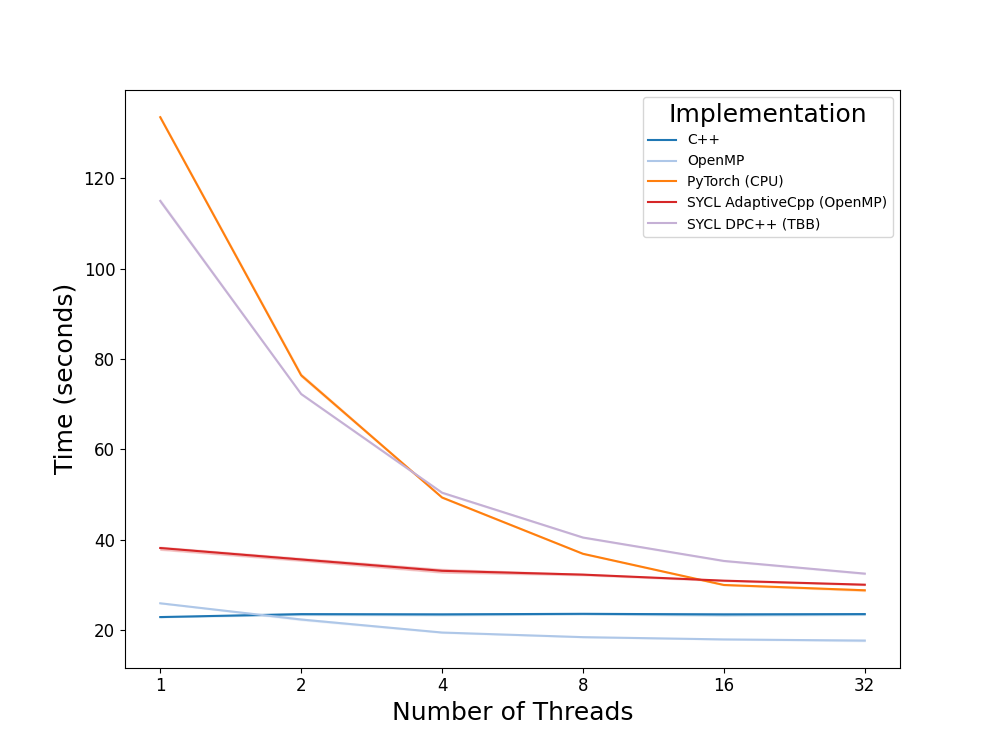

In [20]:
# %%
if strong.exists():
    display(Markdown("## Strong Scaling"))
    display(Image(filename=str(strong)))

## Weak Scaling

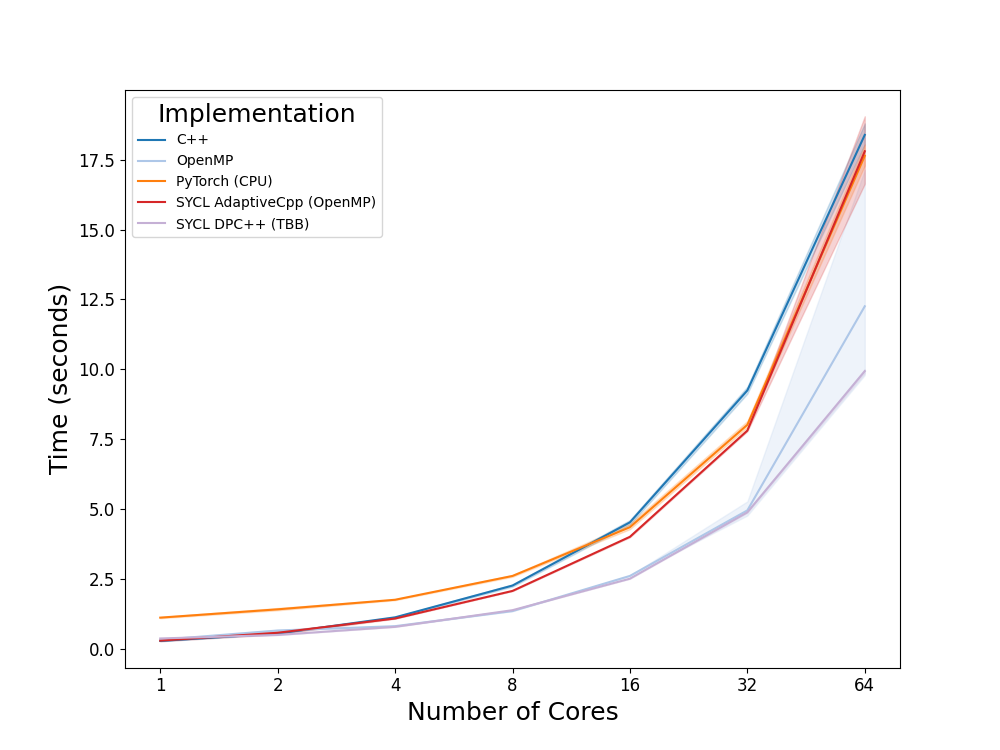

In [21]:
# %%
if weak.exists():
    display(Markdown("## Weak Scaling"))
    display(Image(filename=str(weak)))

## CPU Fixed-Resource Scaling

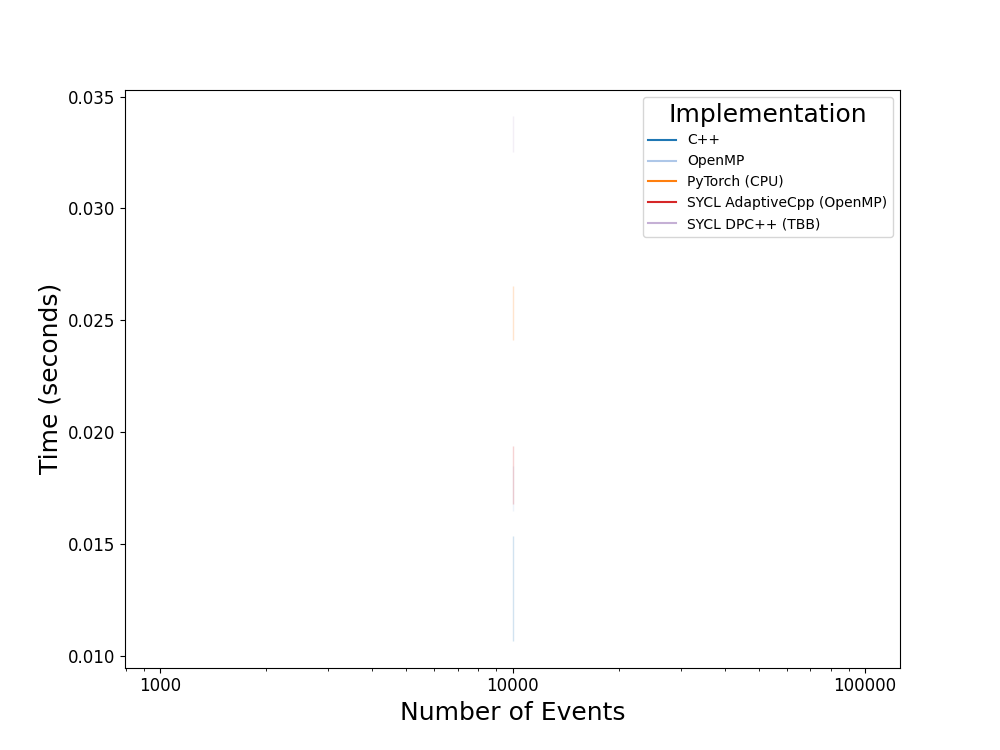

In [22]:
# %%
if cpu.exists():
    display(Markdown("## CPU Fixed-Resource Scaling"))
    display(Image(filename=str(cpu)))

## GPU Fixed-Resource Scaling

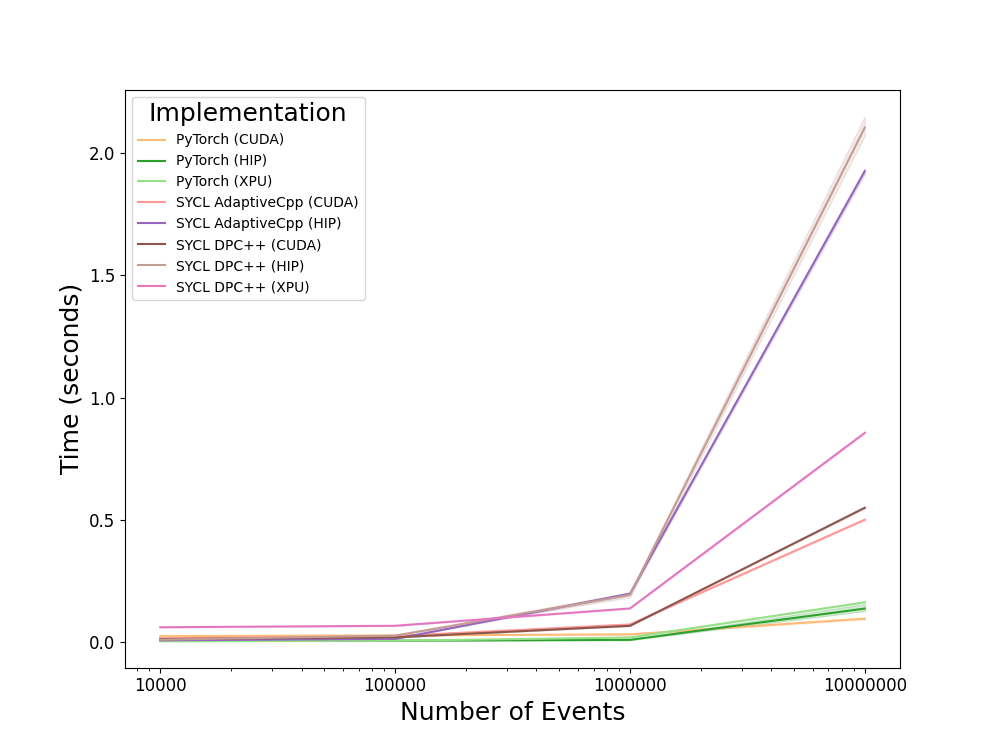

In [23]:
# %%
if gpu.exists():
    display(Markdown("## GPU Fixed-Resource Scaling"))
    display(Image(filename=str(gpu)))

 ## Notes on expected behavior

 - The plotting workflow uses `results/` as the working directory for CSVs.
 - If `results/` is absent, it is bootstrapped from `archived-results/`.
 - This avoids clobbering the archived paper results.
 - Some rerun workflows rebuild backend-specific wrappers before execution.
 - On heterogeneous systems, backend availability is determined by `setup-backends.sh`.

 ---

 ## Suggested artifact validation sequence

 1. Run `make`
 2. Confirm that the figures appear below
 3. Optionally inspect the generated CSVs under `results/`
 4. Optionally run a single rerun target on the current system

In [24]:
# %%
results_dir = ROOT / "results"
if results_dir.exists():
    for p in sorted(results_dir.iterdir()):
        print(p.name + ("/" if p.is_dir() else ""))
else:
    print("results/ does not exist yet.")

frs_scaling_cpu_results/
frs_scaling_cuda_results/
frs_scaling_hip_results/
frs_scaling_xpu_results/
scaling-results-cpu/
scaling-results-gpu/
strong_scaling_results/
ws_scaling_cpu_results/


 ## End of notebook

 This notebook is intended as a lightweight entry point for the artifact rather than a full experimental driver.
For complete automation, prefer the repository `Makefile` and shell scripts.